In [1]:
import numpy as np
import pandas as pd

from scipy.stats import skew
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
from sklearn.metrics.pairwise import cosine_similarity
import statsmodels.api as sm

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns


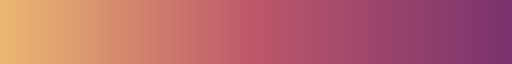

In [2]:
color = '#EBB871'
cmap = LinearSegmentedColormap.from_list('mycmap', [color, '#BD576A', '#7A336E'])
cmap

In [3]:
def fixDate(x):
    if x.day > 9 and x.month > 9:
        return f'{x.month}/{x.day}'
    elif x.day > 9 and x.month < 10:
        return f'0{x.month}/{x.day}'
    elif x.day < 10 and x.month > 9:
        return f'{x.month}/0{x.day}'
    else:
        return f'0{x.month}/0{x.day}'

In [4]:
weekData = pd.read_csv("activity(1).csv")
weekData['start'] = pd.to_datetime(weekData['start'])
weekData['end'] = pd.to_datetime(weekData['end'])
weekData['daydiff'] = weekData['end'].dt.day - weekData['start'].dt.day 
weekData = weekData[weekData['daydiff'] == 0]
weekData['date'] = weekData['start'].apply(lambda x: fixDate(x))

In [5]:
weekData

,location,start,end,age,activity,tagID,daydiff,date
0,Unknown-Inside,2017-06-21 08:10:19.500,2017-06-21 15:43:06.700,0,undefined,1109,0,06/21
1,Unknown-Inside,2017-06-21 15:43:06.700,2017-06-21 17:58:52.250,0,undefined,1109,0,06/21
3,Outside,2017-06-21 08:53:06.300,2017-06-21 09:05:34.900,0,outside-foraging,1230,0,06/21
4,Inside,2017-06-21 09:05:34.900,2017-06-21 09:12:41.300,0,inside,1230,0,06/21
5,Outside-Unknown,2017-06-21 09:12:41.300,2017-06-21 09:34:13.900,0,undefined,1230,0,06/21
...,...,...,...,...,...,...,...,...
1819,Unknown-Inside,2017-06-21 08:32:43.700,2017-06-21 09:57:16.300,0,undefined,930,0,06/21
1822,Inside,2017-06-23 08:24:59.700,2017-06-23 13:05:27.900,1,inside,930,0,06/23
1825,Outside-Unknown,2017-06-25 08:26:20.450,2017-06-25 10:29:44.000,3,undefined,930,0,06/25
1828,Unknown-Inside,2017-06-27 09:14:56.350,2017-06-27 12:05:14.850,6,undefined,930,0,06/27


In [6]:
np.random.seed(42)

# data sintética para 25 abejas y 40 días
N_BEES = 25
N_DAYS = 40

flights = weekData[weekData['location'] == "Outside"].copy()
N_BEES = len(flights['tagID'].unique())
N_DAYS = len(flights['start'].dt.date.unique())
# niveles de actividad distintos en abejas
lambda_bee = np.random.uniform(5, 30, size=N_BEES)


# *D1: Frequency Similarity*

In [7]:
# total vuelos diarios
daily_counts = np.zeros((N_BEES, N_DAYS))

for i in range(N_BEES):
    daily_counts[i] = np.random.poisson(lambda_bee[i], N_DAYS)

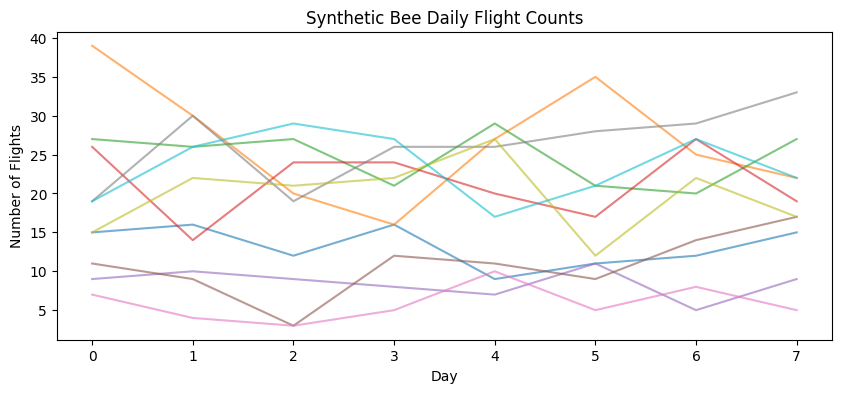

In [8]:
plt.figure(figsize=(10,4))
for i in range(min(10, N_BEES)):
    plt.plot(daily_counts[i], alpha=0.6)

plt.xlabel("Day")
plt.ylabel("Number of Flights")
plt.title("Synthetic Bee Daily Flight Counts")
plt.show()

In [9]:
daily_counts

array([[15., 16., 12., 16.,  9., 11., 12., 15.],
       [39., 30., 20., 16., 27., 35., 25., 22.],
       [27., 26., 27., 21., 29., 21., 20., 27.],
       [26., 14., 24., 24., 20., 17., 27., 19.],
       [ 9., 10.,  9.,  8.,  7., 11.,  5.,  9.],
       [11.,  9.,  3., 12., 11.,  9., 14., 17.],
       [ 7.,  4.,  3.,  5., 10.,  5.,  8.,  5.],
       [19., 30., 19., 26., 26., 28., 29., 33.],
       [15., 22., 21., 22., 27., 12., 22., 17.],
       [19., 26., 29., 27., 17., 21., 27., 22.],
       [ 7.,  2.,  8.,  5.,  5.,  3.,  4.,  8.],
       [20., 30., 38., 29., 29., 22., 32., 27.],
       [32., 39., 41., 33., 26., 29., 28., 34.],
       [15., 11.,  7.,  9., 11., 13., 14.,  6.],
       [16., 10., 10.,  5., 14.,  7.,  8.,  4.],
       [ 7.,  9.,  8., 10.,  9., 12.,  5., 11.],
       [ 9., 19., 13., 16., 11., 13.,  7., 10.],
       [13., 18., 16., 16., 15., 22., 18., 16.],
       [24., 17., 11., 12., 18., 14., 14., 15.],
       [12., 15., 11., 18., 14.,  8., 14., 17.],
       [15., 17., 18

In [10]:
daily_counts = pd.crosstab(flights.tagID, flights.date, margins=False).apply(lambda x: x.tolist(), axis=1).tolist()
daily_counts = np.array(daily_counts)
daily_counts

array([[ 3,  0,  0,  1,  0,  0,  0,  0],
       [ 1,  0,  0,  1,  2,  2,  5,  1],
       [ 3,  2,  1,  0,  0,  0,  1,  0],
       [ 1,  1,  2,  1,  1,  1,  1,  1],
       [ 4,  8,  7,  2,  2,  7,  6,  0],
       [ 4,  4,  4,  3,  0,  2,  3,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0],
       [39,  2, 19,  0,  0,  0,  0,  0],
       [ 3,  3,  5,  2,  3,  4,  8,  0],
       [ 5,  1,  3,  1,  2,  2,  5,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0],
       [ 9,  9,  3,  3,  0,  0,  0,  0],
       [ 1,  2,  0,  0,  0,  0,  0,  0],
       [24,  6, 23,  4,  5, 21, 14, 26],
       [ 2,  1,  9,  4,  6,  2,  5,  0],
       [ 6,  3,  5,  1,  7,  2,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  1,  1,  2,  1,  3,  0],
       [10,  2,  2,  4,  0,  0,  0,  0],
       [ 1,  3,  0,  2,  2,  1,  4,  0],
       [ 1,  2,  2,  1,  0, 15,  3,  4],
       [ 4,  3,  0,  0,  0,  0,  0,  0],
       [ 5,  3,  1,  1,  6,  3,  7,  1],
       [ 1,  1, 

## A) Euclidean

In [11]:
mu = daily_counts.mean(axis=1)
variance = daily_counts.var(axis=1, ddof=1)

# dispersion index
DI = variance / mu

# skewness
sk = skew(daily_counts, axis=1)

# feature matrix
X_freq = np.column_stack([mu, DI, sk])

freq_df = pd.DataFrame(
    X_freq,
    columns=["MeanFlights","DispersionIndex","Skewness"]
)

freq_df.head()

,MeanFlights,DispersionIndex,Skewness
0,0.500,2.285714,1.875000
1,1.500,1.714286,1.333333
2,0.875,1.448980,0.892594
3,1.125,0.111111,2.267787
4,4.500,1.904762,-0.273861


In [12]:
# hay que standarizar la data pues está en diferentes dimensiones
scaler = StandardScaler()

X_freq_norm = scaler.fit_transform(X_freq)

In [13]:
D_freq = squareform(pdist(X_freq_norm, metric="euclidean"))

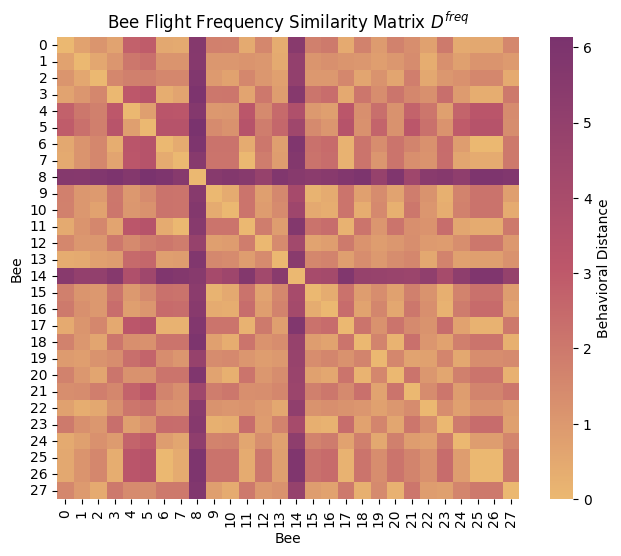

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    D_freq,
    cmap=cmap,
    square=True,
    cbar_kws={"label":"Behavioral Distance"}
)

plt.title("Bee Flight Frequency Similarity Matrix $D^{freq}$")
plt.xlabel("Bee")
plt.ylabel("Bee")

plt.show()

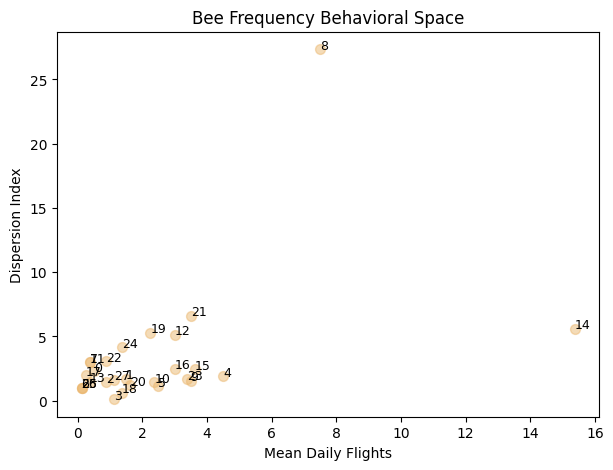

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(mu, DI, s=50, color=color,alpha=0.5)

for i in range(N_BEES):
    plt.text(mu[i], DI[i], str(i), fontsize=9)

plt.xlabel("Mean Daily Flights")
plt.ylabel("Dispersion Index")
plt.title("Bee Frequency Behavioral Space")

plt.show()

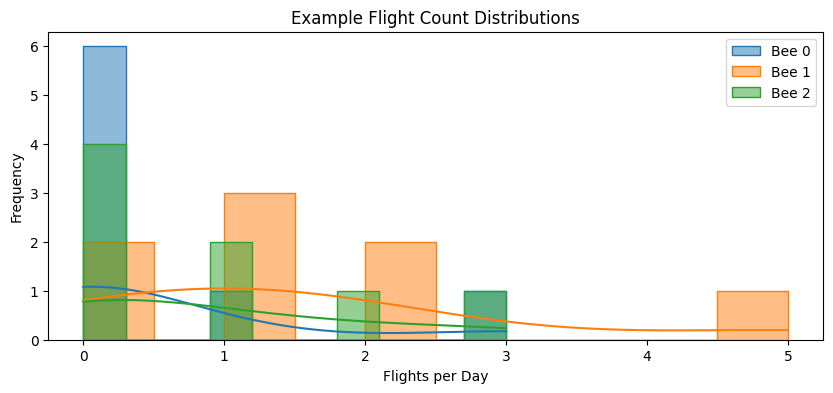

In [16]:

plt.figure(figsize=(10,4))

plot_colors = ["C0", "C1", "C2"]
for i in range(3):
    sns.histplot(
        x=daily_counts[i],
        bins=10,
        kde=True,
        label=f"Bee {i}",
        element="step",
        color=plot_colors[i]
    )

plt.xlabel("Flights per Day")
plt.ylabel("Frequency")
plt.title("Example Flight Count Distributions")
plt.legend()
plt.show()


## B) Wasserstein

In [17]:
N = daily_counts.shape[0]

D_freq_w = np.zeros((N,N))

for i in range(N):
    for j in range(N):
        D_freq_w[i,j] = wasserstein_distance(
            daily_counts[i],
            daily_counts[j]
        )

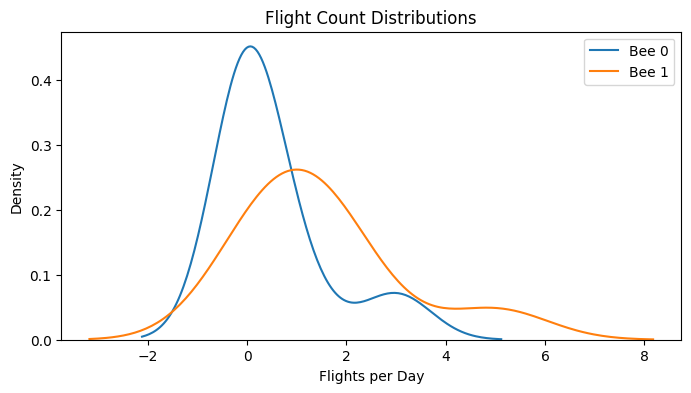

In [18]:

plt.figure(figsize=(8,4))

sns.kdeplot(x=daily_counts[0], label="Bee 0", color="C0")
sns.kdeplot(x=daily_counts[1], label="Bee 1", color="C1")

plt.title("Flight Count Distributions")
plt.xlabel("Flights per Day")
plt.legend()
plt.show()


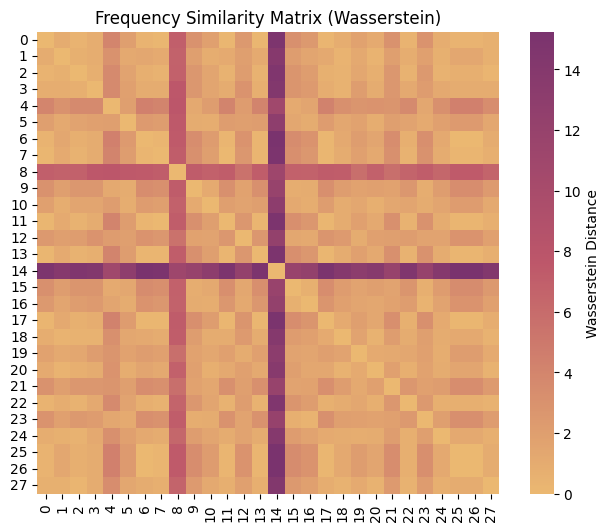

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    D_freq_w,
    cmap=cmap,
    square=True,
    cbar_kws={"label":"Wasserstein Distance"}
)

plt.title("Frequency Similarity Matrix (Wasserstein)")
plt.show()

# *D2: Duration Similarity*

In [20]:
N_BEES = daily_counts.shape[0]

durations = {}

for i in range(N_BEES):

    n_flights = int(daily_counts[i].sum())

    mean_dur = np.random.uniform(5,20)

    durations[i] = np.random.lognormal(
        mean=np.log(mean_dur),
        sigma=0.4,
        size=n_flights
    )

durations

{0: array([13.84019633, 10.95377349,  5.70125142, 12.36255951]),
 1: array([ 5.54556513,  8.21759089,  4.36304216,  9.42931933, 13.4589483 ,
         4.64109121,  4.49014021,  9.59688654, 10.0937235 ,  4.35332937,
         4.53583963,  4.79402856]),
 2: array([ 6.90035395,  6.77781163,  4.76142858,  6.36656917,  6.72470348,
        13.5592417 ,  9.65745198]),
 3: array([13.07184556, 17.83047686, 23.82230811, 11.60697084, 21.19273764,
        19.43888699, 22.14640467, 20.41688221, 48.5607075 ]),
 4: array([ 6.87809201,  6.65777265, 10.564565  ,  6.59430601,  6.93767797,
         7.90984979,  7.28629395,  5.29057358, 11.63150485, 12.86830261,
         9.70656233,  7.27710916,  6.38065308,  6.38471418, 21.72155957,
        12.31096182,  6.04547899,  9.03615616,  7.31802688, 10.68536342,
        10.5144909 , 13.05013674,  6.02027035,  8.82200236,  4.20357753,
         5.11623404, 12.04916165,  5.78391757,  6.04354784,  8.43208034,
        11.17030773,  5.53462621,  2.10229839,  5.9730964 ,

In [21]:
flights['dur'] = flights['end'] - flights['start']
flights['dur'] = flights['dur'].apply(lambda x: x.total_seconds())
durations = flights.groupby('tagID')['dur'].apply(list).apply(lambda x: np.array(x)).tolist()
durations 

[array([  999.35,  1277.4 ,  5677.9 , 19203.15]),
 array([ 6911.35,  2958.65,  3368.35,  5936.05,  1675.5 , 12281.2 ,
         2401.2 ,  1978.8 ,  4741.1 ,  5752.4 ,  2536.85,  3809.7 ]),
 array([   30.9 ,    88.2 , 12807.25,   170.4 ,  3882.5 ,    61.4 ,
        11275.3 ]),
 array([ 71.2 ,  79.4 , 118.  ,  55.  ,  27.25,  38.85,  60.6 ,  48.6 ,
         37.25]),
 array([  77.  , 1031.85, 1421.25, 1829.  ,   49.2 ,  472.15,  713.2 ,
         781.  ,  801.  , 1177.9 , 1069.  ,   75.35,  807.9 ,  876.8 ,
         880.65,  753.7 ,  897.15, 1047.65, 1344.65,   62.9 , 1168.85,
         912.55,   26.95,   52.65,   88.65,   46.75,  614.55,   26.65,
          52.15,  173.05,   40.25, 1911.45, 1062.7 , 1008.8 , 3583.7 ,
         873.15]),
 array([1948.55, 1099.05, 1148.3 , 1905.55, 1581.7 ,  853.4 , 1073.5 ,
        2086.4 ,  703.45,  978.35, 2117.9 , 2402.45, 2743.7 ,   26.65,
          21.45,  836.9 ,  848.1 ,  983.85, 1133.65, 1475.  ]),
 array([8158.35]),
 array([1996.2, 3284.8, 7581.4]),
 

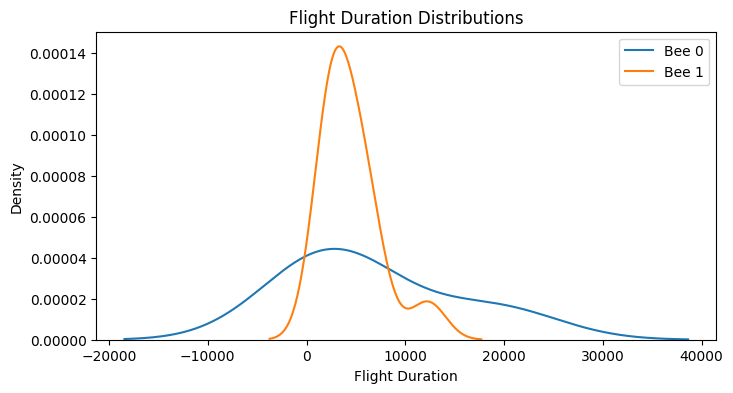

In [22]:

plt.figure(figsize=(8,4))

sns.kdeplot(x=durations[0], label="Bee 0", color="C0")
sns.kdeplot(x=durations[1], label="Bee 1", color="C1")

plt.xlabel("Flight Duration")
plt.title("Flight Duration Distributions")
plt.legend()

plt.show()


In [23]:
D_dur = np.zeros((N_BEES,N_BEES))

for i in range(N_BEES):
    for j in range(N_BEES):

        D_dur[i,j] = wasserstein_distance(
            durations[i],
            durations[j]
        )

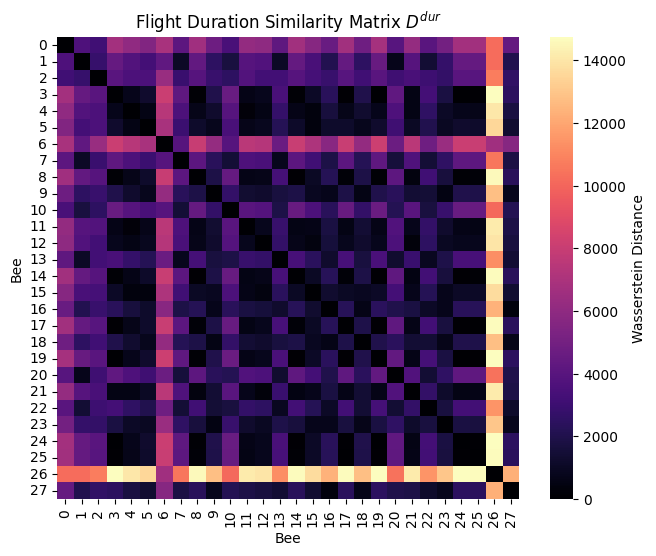

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    D_dur,
    cmap="magma",
    square=True,
    cbar_kws={"label":"Wasserstein Distance"}
)

plt.title("Flight Duration Similarity Matrix $D^{dur}$")
plt.xlabel("Bee")
plt.ylabel("Bee")

plt.show()

## Joint Behavioral: frequency vs duration

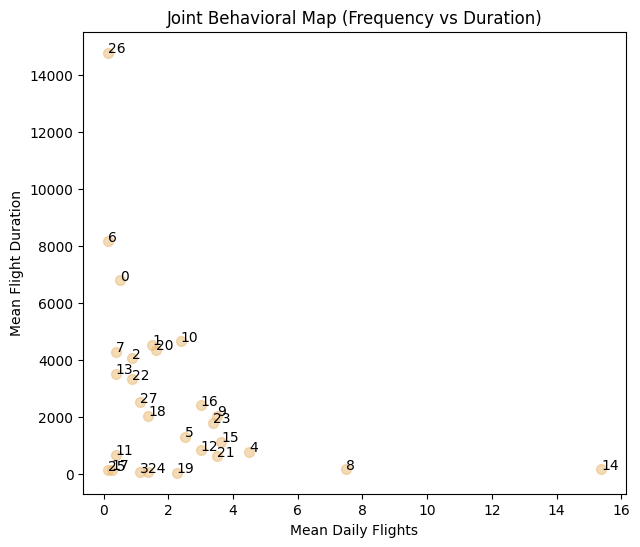

In [25]:
mean_flights = daily_counts.mean(axis=1)

mean_duration = np.array([
    durations[i].mean() for i in range(N_BEES)
])

plt.figure(figsize=(7,6))

plt.scatter(mean_flights, mean_duration, s=50, color=color, alpha=0.5)

for i in range(N_BEES):
    plt.text(mean_flights[i], mean_duration[i], str(i))

plt.xlabel("Mean Daily Flights")
plt.ylabel("Mean Flight Duration")

plt.title("Joint Behavioral Map (Frequency vs Duration)")

# plt.grid(alpha=0.3)
plt.show()

# *D3: Cosine Similarity*

In [26]:
flight_times_start = {}
flight_times_end = {}

for i in range(N_BEES):
    n_flights = len(durations[i])
    # generate random start times
    start_times = np.random.uniform(0,24,durations[i].size)
    end_times = start_times + durations[i]
    # clip at 24 hours
    end_times = np.clip(end_times,0,24)
    
    flight_times_start[i] = start_times
    flight_times_end[i] = end_times

In [27]:
# Freedman–Diaconis: esta es la manera correcta de seleccionar el tamaño del bin
all_start_times = np.concatenate(list(flight_times_start.values()))
h = 2 * (np.percentile(all_start_times,75) - np.percentile(all_start_times,25)) * len(all_start_times)**(-1/3)
n_bins = min(int(np.ceil(24/h)),48)
bins = np.linspace(0,24,n_bins+1)

schedule_vectors = []
for i in range(N_BEES):
    hist,_ = np.histogram(flight_times_start[i], bins=bins)
    hist = hist / hist.sum()  # normalize
    schedule_vectors.append(hist)
schedule_vectors = np.array(schedule_vectors)

In [28]:
D_shift = 1 - cosine_similarity(schedule_vectors)

Text(0.5, 0.98, 'Clustered Similarity Matrix: Flight Schedule (from actual data)')

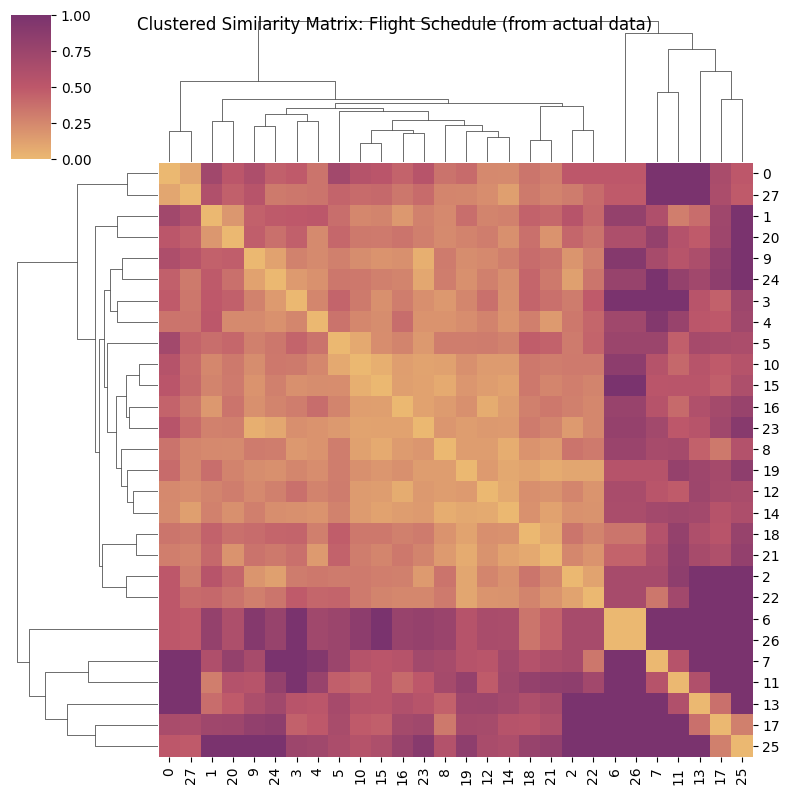

In [29]:
sns.clustermap(
    D_shift,
    cmap=cmap,
    figsize=(8,8),
    method="average",
)
plt.suptitle("Clustered Similarity Matrix: Flight Schedule (from actual data)")

# *D4: Trend similarity* 

In [30]:
mean_durations = np.empty((N_BEES, N_DAYS))

for i in range(N_BEES):
    idx = 0
    for d in range(N_DAYS):
        n_flights = int(daily_counts[i, d])
        if n_flights > 0:
            mean_durations[i,d] = durations[i][idx:idx+n_flights].mean()
            idx += n_flights
        else:
            mean_durations[i,d] = np.nan  # explicitly mark as NaN cuando son 0

In [31]:
trend_vectors_mols = np.zeros((N_BEES, 2))  # frequency slope, duration slope
days = np.arange(N_DAYS)

for i in range(N_BEES):
    valid_idx = ~np.isnan(mean_durations[i])
    if valid_idx.sum() > 1:
        Y = np.vstack([daily_counts[i, valid_idx], mean_durations[i, valid_idx]]).T  # shape: (days, 2)
        X = sm.add_constant(days[valid_idx])  # add intercept
        model = sm.OLS(Y, X).fit()  # Multivariate OLS
        slopes = model.params[1,:]   # slope for freq and duration
        trend_vectors_mols[i] = slopes
    else:
        trend_vectors_mols[i] = [0.0, 0.0]

In [32]:
D_trend = squareform(pdist(trend_vectors_mols, metric="euclidean"))

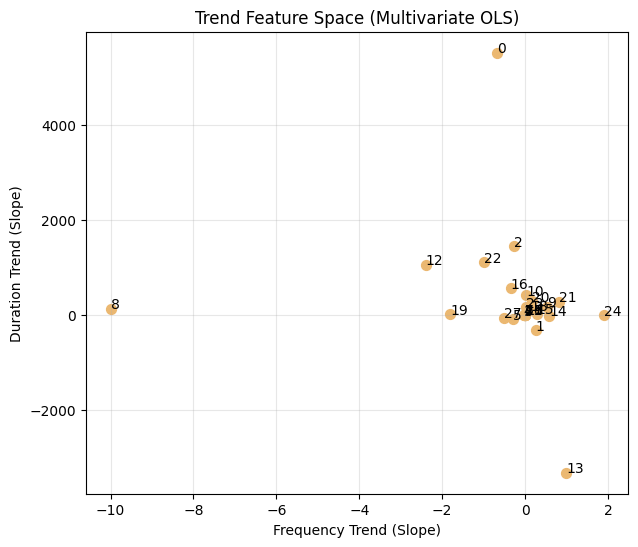

In [33]:
plt.figure(figsize=(7,6))
plt.scatter(trend_vectors_mols[:,0], trend_vectors_mols[:,1], s=50,color=color)
for i in range(N_BEES):
    plt.text(trend_vectors_mols[i,0], trend_vectors_mols[i,1], str(i))
plt.xlabel("Frequency Trend (Slope)")
plt.ylabel("Duration Trend (Slope)")
plt.title("Trend Feature Space (Multivariate OLS)")
plt.grid(alpha=0.3)
plt.show()

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


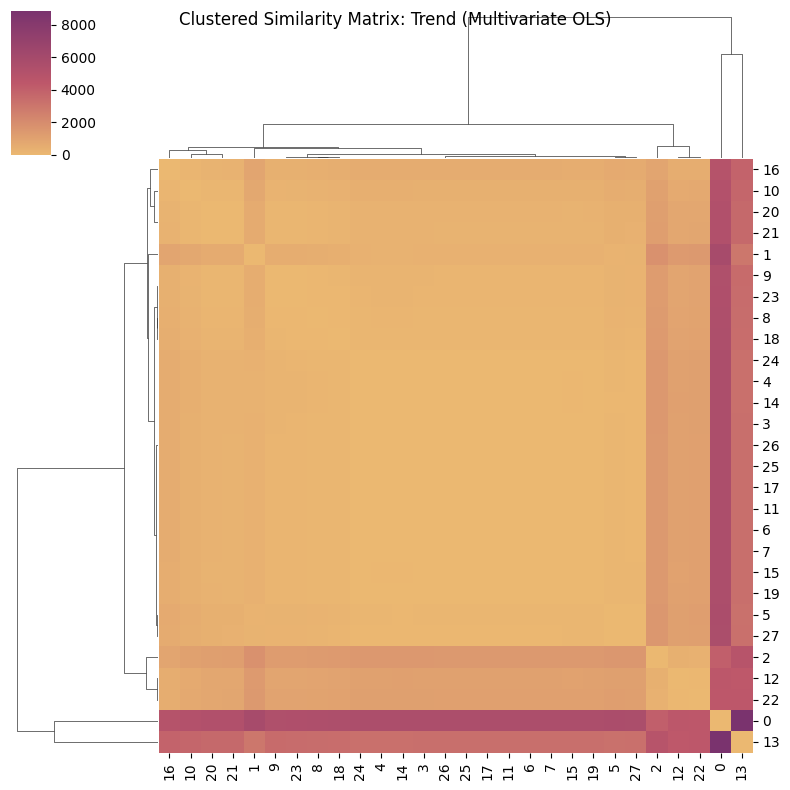

In [34]:
D_df = pd.DataFrame(D_trend, index=np.arange(N_BEES), columns=np.arange(N_BEES))
#linkage = 
DF_dism = D_trend
#DF_dism[0][0] = np.float64(-2.220446049250313e-16)
#linkage = hc.linkage(DF_dism, method='average')

sns.clustermap(
    #normalize(D_trend, axis=0),
    #D_trend/D_trend.max(),
    #D_trend,
    #D_shift,
    DF_dism,
    #row_linkage = linkage,
    #pdist(trend_vectors_mols, metric="euclidean"),
    #trend_vectors_mols,
    cmap=cmap,
    figsize=(8,8),
    #metric='precomputed',
    method="average"
)
plt.suptitle("Clustered Similarity Matrix: Trend (Multivariate OLS)")
plt.show()

Text(0.5, 0.98, 'Trend Similarity: Duration Only')

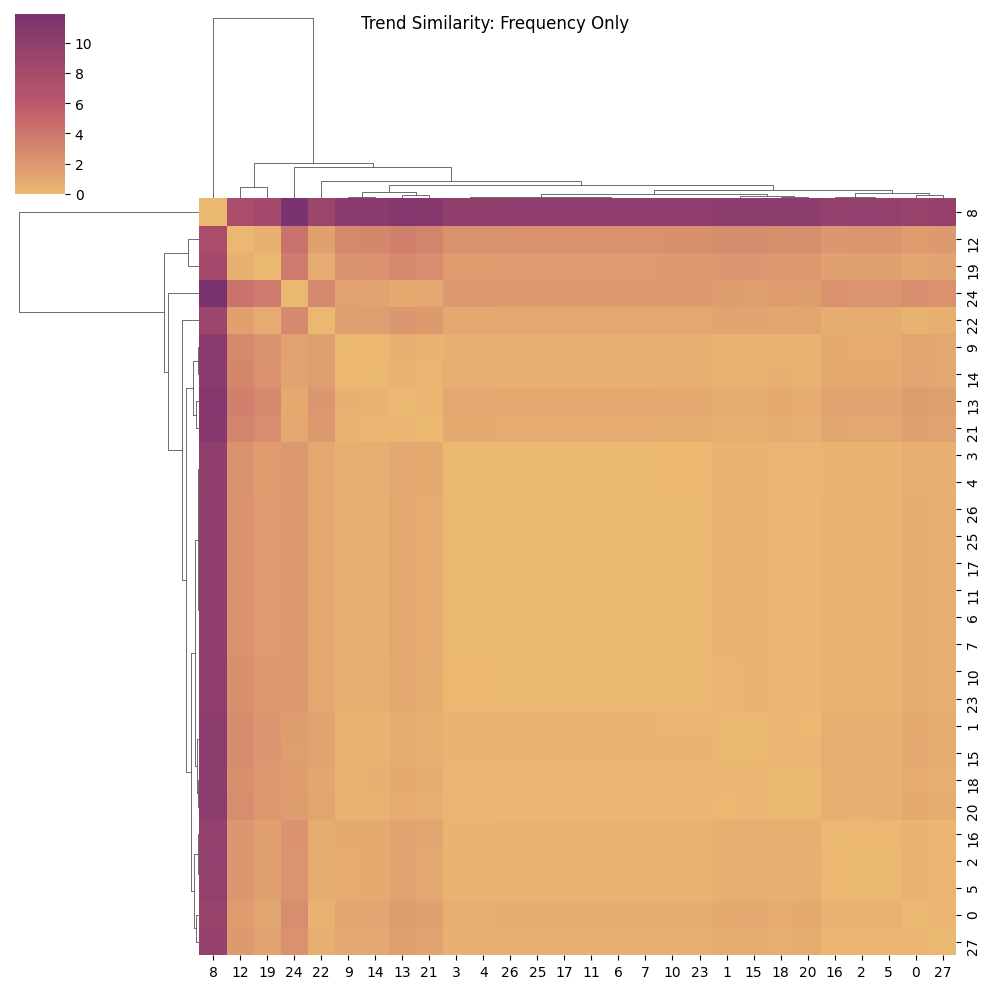

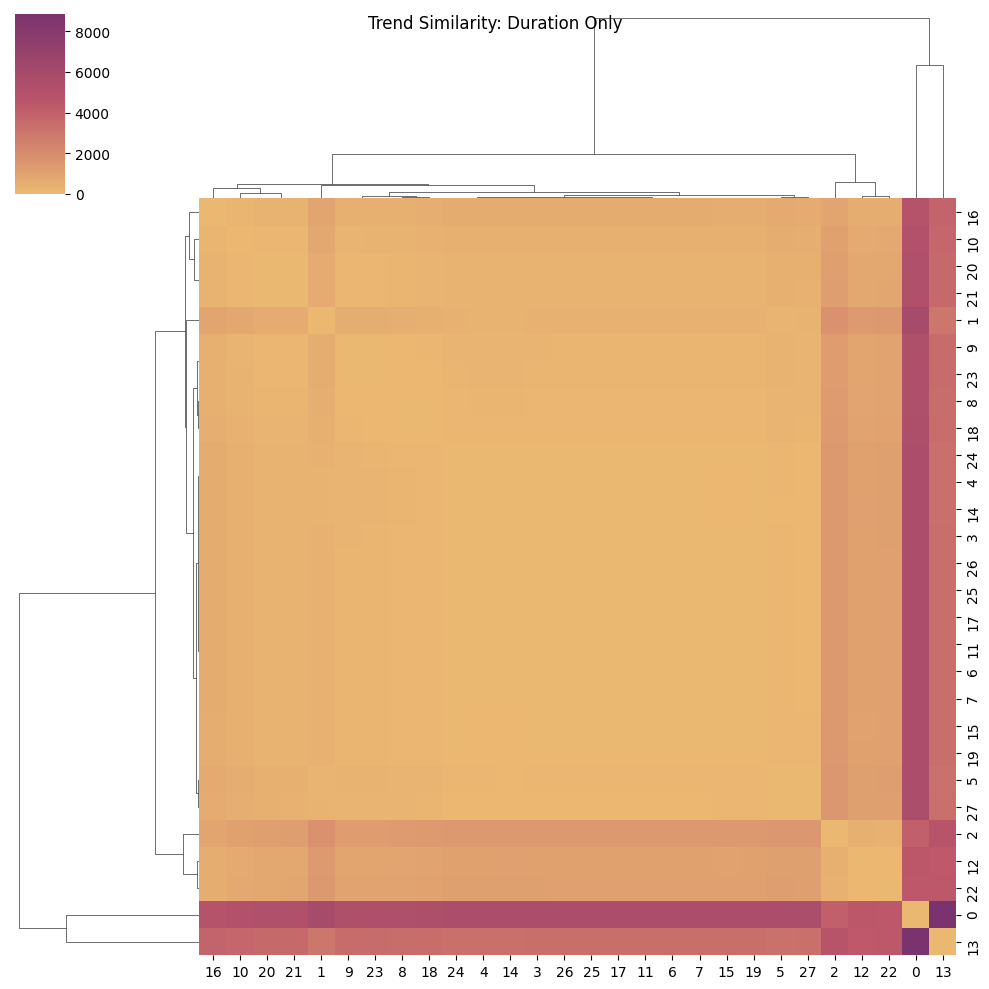

In [35]:
# frequency-only slope heatmap
D_trend_freq = squareform(pdist(trend_vectors_mols[:,0].reshape(-1,1), metric="euclidean"))
D_trend_freq[0][0] = np.float64(-2.220446049250313e-16)
sns.clustermap(D_trend_freq, cmap=cmap)
plt.suptitle("Trend Similarity: Frequency Only")

# duration-only slope heatmap
D_trend_dur = squareform(pdist(trend_vectors_mols[:,1].reshape(-1,1), metric="euclidean"))
D_trend_dur[0][0] = np.float64(-2.220446049250313e-16)
sns.clustermap(D_trend_dur, cmap=cmap)
plt.suptitle("Trend Similarity: Duration Only")

# *D Total: multidimensional*

In [36]:
def normalize_matrix(D):
    D = np.array(D)
    return D / D.max()  # simple max-normalization

In [37]:
D_freq_norm  = normalize_matrix(D_freq)
D_dur_norm   = normalize_matrix(D_dur)
D_shift_norm = normalize_matrix(D_shift)
D_trend_norm = normalize_matrix(D_trend)

In [38]:
variances = [
    np.var(D_freq_norm),
    np.var(D_dur_norm),
    np.var(D_shift_norm),
    np.var(D_trend_norm)
]

weights_unsup = np.array(variances) / np.sum(variances)
print("Unsupervised weights:", weights_unsup)

Unsupervised weights: [0.29081618 0.21536358 0.35888068 0.13493956]


In [39]:
D_total_unsup = (
    weights_unsup[0]*D_freq_norm +
    weights_unsup[1]*D_dur_norm +
    weights_unsup[2]*D_shift_norm +
    weights_unsup[3]*D_trend_norm
)

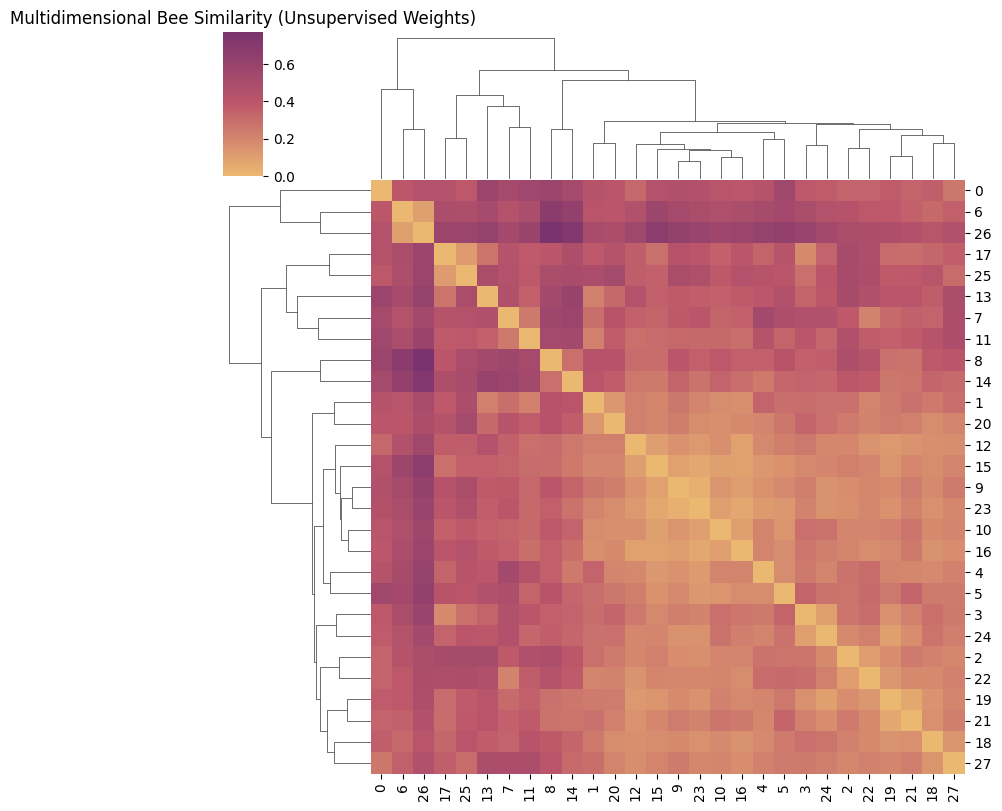

In [40]:
sns.clustermap(D_total_unsup, cmap=cmap, method="average", figsize=(8,8))
plt.title("Multidimensional Bee Similarity (Unsupervised Weights)")
plt.show()

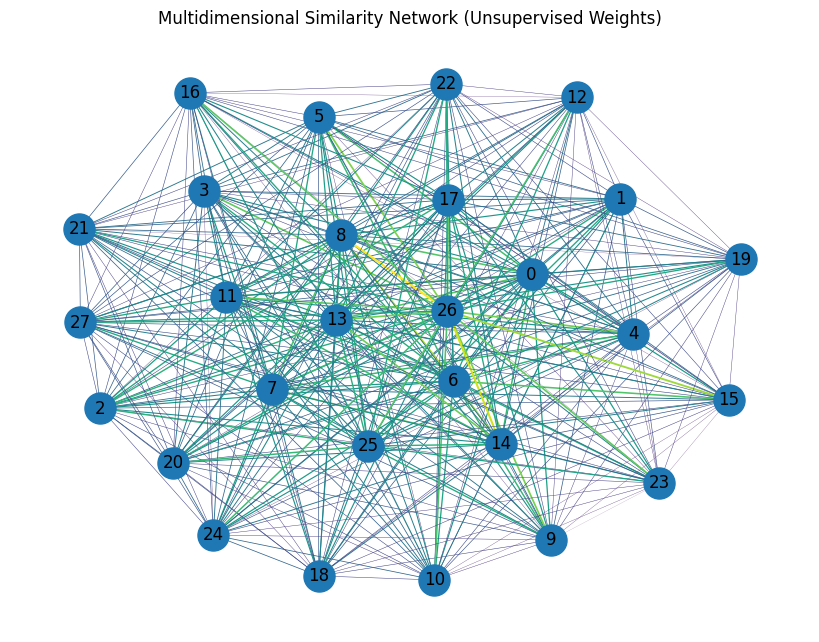

In [41]:
import networkx as nx

G = nx.Graph()
N_BEES = D_total_unsup.shape[0]

for i in range(N_BEES):
    G.add_node(i)

for i in range(N_BEES):
    for j in range(i+1, N_BEES):
        G.add_edge(i,j, weight=D_total_unsup[i,j])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_size=500,
        width=[w*2 for w in weights], edge_color=weights, edge_cmap=plt.cm.viridis)
plt.title("Multidimensional Similarity Network (Unsupervised Weights)")
plt.show()

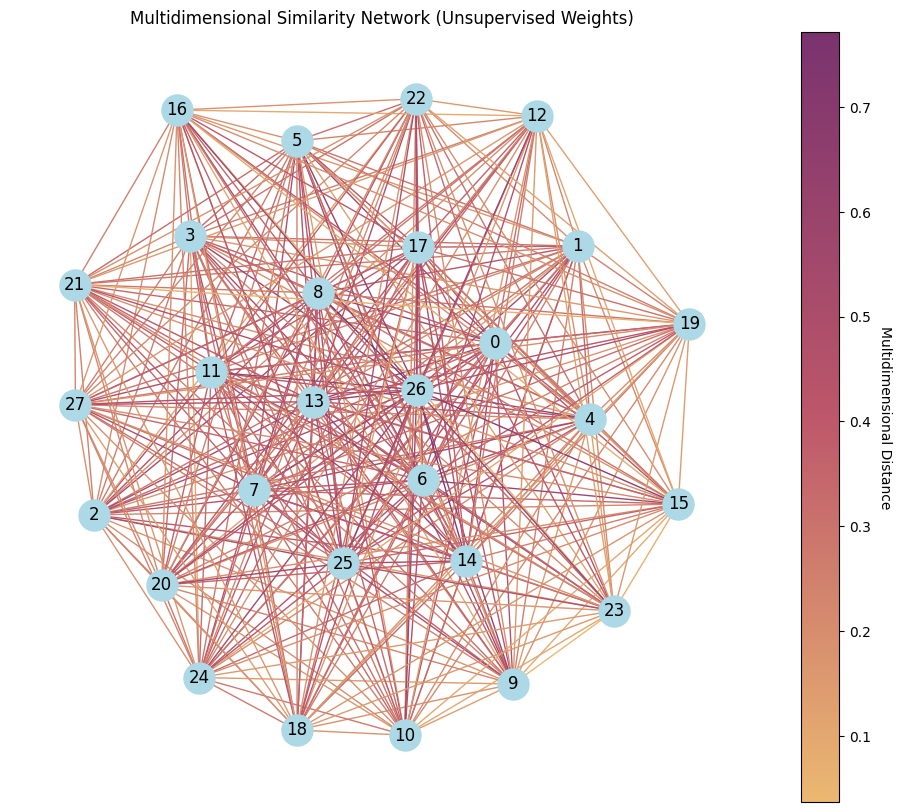

In [42]:

# Create graph
G = nx.Graph()
for i in range(N_BEES):
    G.add_node(i)
for i in range(N_BEES):
    for j in range(i+1, N_BEES):
        G.add_edge(i, j, weight=D_total_unsup[i,j])

# Layout
pos = nx.spring_layout(G, seed=42)

# Extract edge weights for color mapping
edges = G.edges()
weights = np.array([G[u][v]['weight'] for u,v in edges])

# Normalize for colormap
norm = Normalize(vmin=weights.min(), vmax=weights.max())
#cmap = plt.cm.viridis

# Create figure and axes
fig, ax = plt.subplots(figsize=(12,10))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue', ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)

# Draw edges with colormap
nx.draw_networkx_edges(
    G, pos,
    edge_color=weights,
    edge_cmap=cmap,
    edge_vmin=weights.min(),
    edge_vmax=weights.max(),
    # width=2,
    ax=ax
)

# Create ScalarMappable for colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # needed for colorbar

# Add colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Multidimensional Distance", rotation=270, labelpad=15)

plt.title("Multidimensional Similarity Network (Unsupervised Weights)")
plt.axis('off')
plt.show()

# *Cluster Analysis*

In [43]:

# Clean and validate the integrated distance matrix
D_total_clean = np.array(D_total_unsup, dtype=float).copy()
D_total_clean = 0.5 * (D_total_clean + D_total_clean.T)  # enforce symmetry
np.fill_diagonal(D_total_clean, 0.0)

print("Distance matrix shape:", D_total_clean.shape)
print("Symmetric:", np.allclose(D_total_clean, D_total_clean.T))
print("Diagonal is zero:", np.allclose(np.diag(D_total_clean), 0))


Distance matrix shape: (28, 28)
Symmetric: True
Diagonal is zero: True


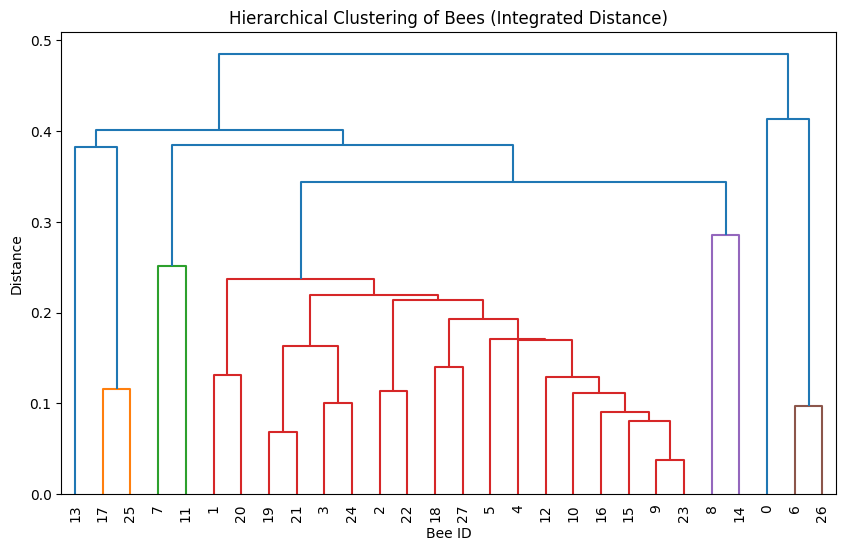

In [44]:

condensed_D_total = squareform(D_total_clean, checks=False)

Z = linkage(condensed_D_total, method='average')

plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    labels=np.arange(D_total_clean.shape[0]),
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering of Bees (Integrated Distance)")
plt.xlabel("Bee ID")
plt.ylabel("Distance")
plt.show()


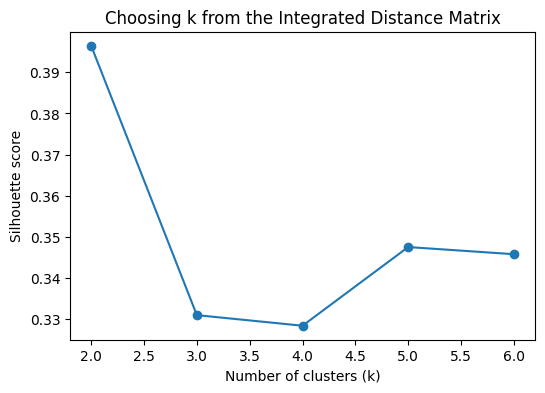

Candidate k values: [2, 3, 4, 5, 6]
Silhouette scores: [0.3964 0.331  0.3284 0.3475 0.3458]
Selected number of clusters: 2
Cluster labels: [1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2]


In [45]:

from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

def agglomerative_from_distance(D, n_clusters, linkage='average'):
    # Compatibility across scikit-learn versions
    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            metric='precomputed',
            linkage=linkage
        )
    except TypeError:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            affinity='precomputed',
            linkage=linkage
        )
    return model.fit_predict(D)

candidate_k = list(range(2, min(7, N_BEES)))
sil_scores = []

for k in candidate_k:
    labels_k = agglomerative_from_distance(D_total_clean, n_clusters=k, linkage='average')
    score_k = silhouette_score(D_total_clean, labels_k, metric='precomputed')
    sil_scores.append(score_k)

best_k = candidate_k[int(np.argmax(sil_scores))]
cluster_labels = agglomerative_from_distance(D_total_clean, n_clusters=best_k, linkage='average') + 1

plt.figure(figsize=(6, 4))
plt.plot(candidate_k, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing k from the Integrated Distance Matrix")
plt.show()

print("Candidate k values:", candidate_k)
print("Silhouette scores:", np.round(sil_scores, 4))
print("Selected number of clusters:", best_k)
print("Cluster labels:", cluster_labels)


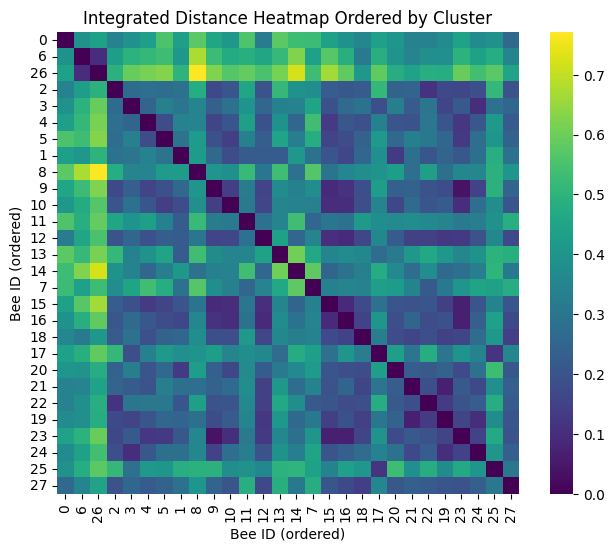

In [46]:

order = np.argsort(cluster_labels)
D_ordered = D_total_clean[order][:, order]
df_ordered = pd.DataFrame(D_ordered, index=order, columns=order)

plt.figure(figsize=(8, 6))
sns.heatmap(df_ordered, cmap='viridis', square=True)
plt.title("Integrated Distance Heatmap Ordered by Cluster")
plt.xlabel("Bee ID (ordered)")
plt.ylabel("Bee ID (ordered)")
plt.show()


In [47]:

from collections import Counter

composition = Counter(cluster_labels)
print("Cluster composition:")
for cluster_id, count in sorted(composition.items()):
    print(f"Cluster {cluster_id}: {count} bees")


Cluster composition:
Cluster 1: 3 bees
Cluster 2: 25 bees


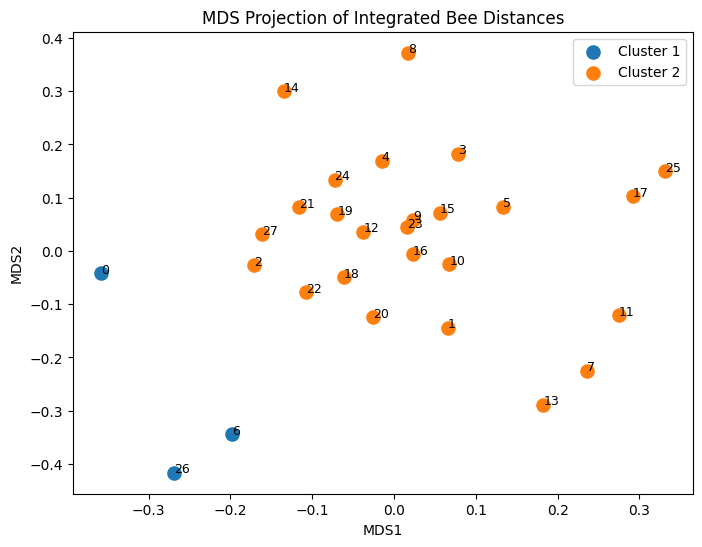

In [48]:

from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    metric='precomputed',
    random_state=42,
    n_init = 4,
    init='random'
)

coords_mds = mds.fit_transform(D_total_clean)

cluster_ids = np.unique(cluster_labels)

plt.figure(figsize=(8, 6))
for cid in cluster_ids:
    idx = np.where(cluster_labels == cid)[0]
    plt.scatter(coords_mds[idx, 0], coords_mds[idx, 1], label=f"Cluster {cid}", s=90)

for i in range(N_BEES):
    plt.text(coords_mds[i, 0], coords_mds[i, 1], str(i), fontsize=9)

plt.legend()
plt.title("MDS Projection of Integrated Bee Distances")
plt.xlabel("MDS1")
plt.ylabel("MDS2")
plt.show()


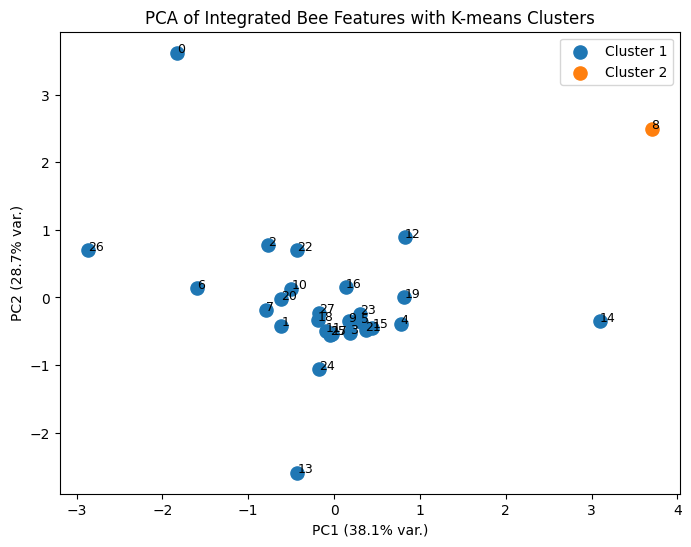

Explained variance ratio: [0.3806 0.2872]
K-means cluster labels: [1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [49]:

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Integrated feature table for feature-based downstream analysis
feature_df = pd.DataFrame({
    "MeanFlights": mu,
    # "FreqDispersionIndex": DI,
    # "FreqSkewness": sk,
    "MeanDuration": mean_duration,
    "TrendFreqSlope": trend_vectors_mols[:, 0],
    "TrendDurationSlope": trend_vectors_mols[:, 1]
})

feature_scaler = StandardScaler()
X_integrated = feature_scaler.fit_transform(feature_df)

pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(X_integrated)

# Use the same number of clusters selected from the distance-based analysis
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_integrated) + 1

plt.figure(figsize=(8, 6))
for cid in np.unique(kmeans_labels):
    idx = np.where(kmeans_labels == cid)[0]
    plt.scatter(coords_pca[idx, 0], coords_pca[idx, 1], label=f"Cluster {cid}", s=90)

for i in range(N_BEES):
    plt.text(coords_pca[i, 0], coords_pca[i, 1], str(i), fontsize=9)

plt.legend()
plt.title("PCA of Integrated Bee Features with K-means Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
plt.show()

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("K-means cluster labels:", kmeans_labels)


In [50]:

cluster_summary = feature_df.copy()
cluster_summary["AgglomerativeCluster"] = cluster_labels
cluster_summary["KMeansCluster"] = kmeans_labels

summary_table = cluster_summary.groupby("AgglomerativeCluster").mean(numeric_only=True).round(3)
summary_table


,MeanFlights,MeanDuration,TrendFreqSlope,TrendDurationSlope,KMeansCluster
AgglomerativeCluster,,,,,
1,0.250,9910.467,-0.222,1839.067,1.00
2,2.635,1820.371,-0.436,73.256,1.04


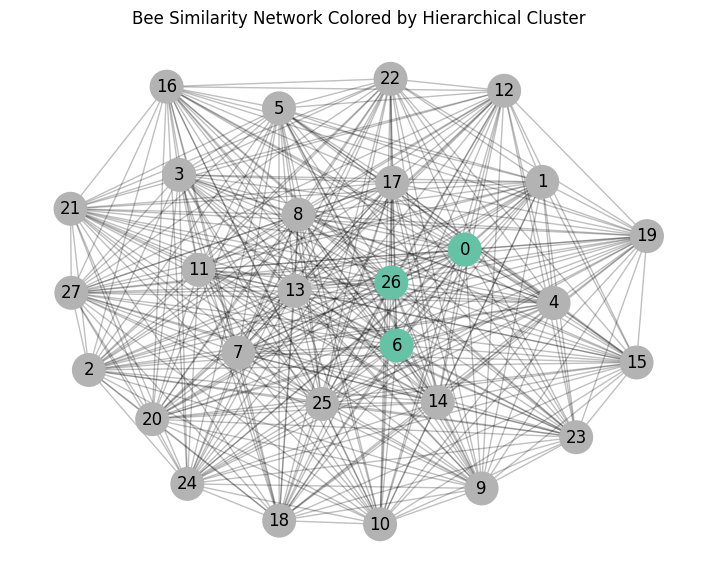

In [51]:

import networkx as nx

G = nx.Graph()
for i in range(N_BEES):
    G.add_node(i, cluster=int(cluster_labels[i]))

for i in range(N_BEES):
    for j in range(i + 1, N_BEES):
        G.add_edge(i, j, weight=D_total_clean[i, j])

pos = nx.spring_layout(G, seed=42)
node_colors = [G.nodes[i]['cluster'] for i in G.nodes()]

plt.figure(figsize=(9, 7))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set2, node_size=550)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, alpha=0.25)
plt.title("Bee Similarity Network Colored by Hierarchical Cluster")
plt.axis('off')
plt.show()
